# Nivel 3 — Algoritmo Genético aplicado a la Detección de Phishing
### Sistemas Inteligentes 1 — Universidad de Caldas
#### v2: pesos continuos mediante codificación binaria de múltiples bits por gen

**Objetivo:** adaptar el Algoritmo Genético (AG) visto en clase —diseñado originalmente para optimizar la función matemática `pruebaopt2D(x, y)`— para que en su lugar **aprenda los pesos óptimos de un filtro heurístico** que clasifique correos como *phishing* (1) o *legítimos* (0), usando un dataset de 100 correos ya vectorizados en 32 características binarias.

Este notebook conserva exactamente la misma estructura del código del profesor (codificación binaria, selección por muestreo estocástico, recombinación de un punto, mutación bit a bit). Esta es la **segunda versión** del proyecto: en la primera versión cada gen era 1 bit y el peso solo podía ser $-1$ o $+1$ (bipolar). Aquí evolucionamos esa idea para que **cada peso se codifique con `k=5` bits**, permitiendo que el AG aprenda **magnitudes continuas** (p. ej. un peso de $+0.74$ o $-0.35$) y no solo la dirección de la evidencia.

Los cambios centrales frente a la versión anterior son:

1. **Cromosoma**: pasa de 32 bits (1 bit/peso) a `l = 160` bits (`k=5` bits/peso).
2. **`decode_individuo` / `decode_poblacion`**: ahora agrupan el cromosoma en bloques de `k` bits y los escalan a un rango continuo $[-1, 1]$, en vez de mapear un solo bit a $\pm1$.
3. **Bucle evolutivo**: la selección, recombinación y mutación **no necesitaron cambiarse**, porque ya estaban escritas en función de `l` (la longitud del cromosoma) y no de un valor fijo — esta es justamente la ventaja de haber vectorizado todo desde el principio.
4. **Gráfica final de pesos**: ahora muestra la magnitud real de cada peso (no solo su signo), con el valor numérico anotado sobre cada barra.

> Nota para la sustentación: cada celda está comentada para poder explicar, frente al docente, qué hace cada bloque y por qué se tomó cada decisión de diseño — incluyendo una comparación empírica al final que justifica, con números, por qué el enfoque continuo es superior al bipolar.


In [1]:
# Librerías utilizadas: numpy para todo el cómputo vectorizado,
# pandas solo para leer el CSV de forma cómoda, matplotlib para graficar.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Fijamos una semilla para que los resultados sean reproducibles durante
# la sustentación (se puede comentar esta línea para ver la variabilidad
# del AG entre corridas distintas).
np.random.seed(42)


## 0. Carga del dataset de correos

El archivo `100correos.csv` contiene 100 correos ya vectorizados: 32 columnas binarias (0/1) que indican la presencia de una característica sospechosa (dominio externo, urgencia en el asunto, solicitud de credenciales, URLs con IP, etc.) y una columna final `label` con la clase real (1 = phishing, 0 = legítimo).

Separamos la matriz de características `X` (100×32) del vector de etiquetas `y` (100,).


In [2]:
# --- Carga del dataset ---
# Si el notebook y el CSV no están en la misma carpeta, ajuste esta ruta.
RUTA_CSV = "/content/sample_data/100correos.csv"

df = pd.read_csv(RUTA_CSV)

nombres_features = df.columns[:-1].tolist()   # las 32 columnas de características
X = df[nombres_features].values.astype(float) # matriz (100 x 32)
y = df["label"].values.astype(int)             # vector (100,)

n_correos, n_bits = X.shape   # n_bits = 32 = número de características = número de pesos a aprender

print(f"Correos cargados:        {n_correos}")
print(f"Características (genes): {n_bits}")
print(f"Correos phishing (1):    {np.sum(y == 1)}")
print(f"Correos legítimos (0):   {np.sum(y == 0)}")


Correos cargados:        100
Características (genes): 32
Correos phishing (1):    58
Correos legítimos (0):   42


## 1. Rediseño del cromosoma y nueva decodificación: Genotipo → Fenotipo continuo

**Versión anterior (bipolar):** 1 bit por característica → 32 bits en total → cada peso solo podía ser $-1.0$ o $+1.0$.

**Nueva versión (continua):** cada uno de los 32 pesos se codifica ahora con `k = 5` bits, así que el cromosoma completo mide

$$l = n\_bits \times k = 32 \times 5 = 160 \text{ bits}$$

Con 5 bits por peso hay $2^5 = 32$ niveles distintos de magnitud disponibles por característica, en vez de solo 2 (antes). La lógica de decodificación, para CADA bloque de 5 bits, es exactamente la misma idea que ya usaba el `decode()` original del profesor (binario → entero → escalado a un rango), solo que ahora se aplica **32 veces en paralelo** (una vez por característica) en lugar de una sola vez para $x$ e $y$:

1. Se reorganiza el cromosoma plano de 160 bits en una matriz de forma `(32, 5)`: cada fila son los 5 bits que codifican el peso de UNA característica.
2. Cada bloque de 5 bits se interpreta como un entero en base 2 (bit más significativo primero): $\text{entero} = b_4\cdot16 + b_3\cdot8 + b_2\cdot4 + b_1\cdot2 + b_0\cdot1$, dando un valor entre 0 y 31.
3. Ese entero se escala linealmente al rango continuo $[-1, 1]$:

$$\text{peso}_i = -1 + \frac{\text{entero}_i}{31}\times 2$$

**Dato clave para el Q&A:** el caso bipolar de la primera versión es, matemáticamente, el caso particular `k=1` de esta misma fórmula: con un solo bit, el entero solo puede ser 0 o 1, que al escalarse a $[-1,1]$ da exactamente $-1.0$ o $+1.0$. No son dos algoritmos distintos — es la **misma** función de decodificación evaluada en dos resoluciones distintas. Esto se verifica empíricamente al final del notebook.


In [3]:
# --- Nueva decodificación binaria (Genotipo -> Fenotipo continuo) ---

k_bits_por_peso = 5                  # resolución: 2^5 = 32 niveles de magnitud por peso
l = n_bits * k_bits_por_peso          # longitud total del cromosoma: 32 x 5 = 160 genes


def decode_individuo(ind, k=k_bits_por_peso, rango=(-1.0, 1.0)):
    '''
    Convierte UN cromosoma de l=n_bits*k bits en su fenotipo: un vector de
    n_bits pesos CONTINUOS (no solo +1/-1 como en la versión anterior).

    ind   : array (l,) con valores en {0,1}
    k     : cuántos bits codifican cada peso (por defecto 5 -> 32 niveles)
    rango : (lo, hi) al que se escala cada peso decodificado

    return: array (n_bits,) con valores flotantes dentro de `rango`
    '''
    bloques = ind.reshape(n_bits, k)                  # (n_bits, k): una fila de k bits por característica
    potencias = 2 ** np.arange(k - 1, -1, -1)          # [2^(k-1), ..., 2, 1]  (bit más significativo primero)
    enteros = bloques @ potencias                       # (n_bits,) -> producto punto: valores en [0, 2^k - 1]
    max_val = 2**k - 1
    lo, hi = rango
    pesos = lo + (enteros / max_val) * (hi - lo)        # escalado lineal al rango continuo
    return pesos


def decode_poblacion(pob, k=k_bits_por_peso, rango=(-1.0, 1.0)):
    '''
    Igual que decode_individuo, pero para TODA la población a la vez:
    ni un solo bucle fila por fila, solo reshape + producto matricial.

    pob   : matriz (n_individuos, l)
    return: matriz (n_individuos, n_bits) con los pesos continuos de cada individuo
    '''
    n_individuos = pob.shape[0]
    bloques = pob.reshape(n_individuos, n_bits, k)     # (n_individuos, n_bits, k)
    potencias = 2 ** np.arange(k - 1, -1, -1)            # [2^(k-1), ..., 1]
    enteros = bloques @ potencias                          # (n_individuos, n_bits) -- numpy hace el producto
                                                            # matriz-vector para cada individuo de la pila
    max_val = 2**k - 1
    lo, hi = rango
    pesos = lo + (enteros / max_val) * (hi - lo)
    return pesos


# --- Prueba rápida de la nueva decodificación ---
ind_prueba = np.random.randint(0, 2, l)              # ahora un cromosoma de 160 bits
pesos_prueba = decode_individuo(ind_prueba)
print(f"Longitud del cromosoma de prueba: {len(ind_prueba)} bits")
print("Primeros 5 bloques de 5 bits     :", ind_prueba[:25].reshape(5, 5))
print("Primeros 5 pesos decodificados   :", np.round(pesos_prueba[:5], 3))


Longitud del cromosoma de prueba: 160 bits
Primeros 5 bloques de 5 bits     : [[0 1 0 0 0]
 [1 0 0 0 1]
 [0 0 0 0 1]
 [0 1 1 1 0]
 [1 0 1 1 1]]
Primeros 5 pesos decodificados   : [-0.484  0.097 -0.935 -0.097  0.484]


## 2. Función de Fitness (sin cambios en su lógica)

La función de aptitud sigue siendo el **Accuracy** del filtro, calculado exactamente igual que antes:

$$\text{score} = \mathbf{x}\cdot\mathbf{w}, \qquad \hat{y} = \mathbb{1}[\text{score} > 0], \qquad \text{Accuracy} = \frac{1}{N}\sum_j \mathbb{1}[\hat{y}_j = y_j]$$

Esto es importante para la sustentación: **la función de fitness no sabe ni le importa** si los pesos que recibe son bipolares ($\pm1$) o continuos ($[-1,1]$) — solo necesita un vector de 32 números para hacer el producto punto. Esa separación entre "cómo se decodifica el cromosoma" (`decode`) y "cómo se evalúa la calidad" (`fitness`) es la que permitió evolucionar el modelo sin tocar ni una línea de esta función.


In [4]:
# --- Función de aptitud (fitness): Accuracy del clasificador heurístico ---
# (idéntica a la versión bipolar: no depende de si los pesos son discretos o continuos)

def fitness(pesos, X, y, umbral=0.0):
    '''
    Calcula el Accuracy del filtro para UN individuo (un vector de 32 pesos).
    '''
    scores = X @ pesos                       # (n_correos,) : combinación lineal ponderada
    predicciones = (scores > umbral).astype(int)
    return np.mean(predicciones == y)         # accuracy = proporción de aciertos


def fitness_poblacion(POB_PESOS, X, y, umbral=0.0):
    '''
    Versión vectorizada: calcula el Accuracy de TODA la población a la vez.
    POB_PESOS : array (n_individuos, 32) -> fenotipos de toda la población
    Devuelve  : array (n_individuos,)    -> accuracy de cada individuo
    '''
    SCORES = POB_PESOS @ X.T                  # (n_individuos, n_correos)
    PRED = (SCORES > umbral).astype(int)      # predicción de cada individuo para cada correo
    return (PRED == y).mean(axis=1)           # accuracy por individuo (broadcasting con y)


# --- Líneas base, para tener un punto de comparación antes de correr el AG ---
acc_aleatoria   = fitness(pesos_prueba, X, y)
acc_todos_pos   = fitness(np.ones(n_bits), X, y)            # filtro "todo cuenta como phishing"
acc_mayoritaria = max(np.mean(y == 1), np.mean(y == 0))      # predecir siempre la clase mayoritaria

print(f"Accuracy de un individuo aleatorio (continuo): {acc_aleatoria:.2%}")
print(f"Accuracy con pesos todos en +1.0               : {acc_todos_pos:.2%}")
print(f"Accuracy de la clase mayoritaria                : {acc_mayoritaria:.2%}  <- línea base a superar")


Accuracy de un individuo aleatorio (continuo): 37.00%
Accuracy con pesos todos en +1.0               : 59.00%
Accuracy de la clase mayoritaria                : 58.00%  <- línea base a superar


## 3. Adaptación del bucle evolutivo

Se conserva exactamente la misma mecánica del SGA del profesor: **selección** por muestreo estocástico con resto, **recombinación** de un punto, **mutación** bit a bit, y la misma condición de parada por baja diversidad. La diferencia clave frente a la versión bipolar es que **no se modificó ni una línea** de selección/recombinación/mutación: todo ese código ya estaba escrito en función de `l` (la longitud del cromosoma) y de la forma `(n, l)` de la población, nunca de un valor fijo "32". Al cambiar `l` de 32 a 160 en la celda del Paso 1, el resto del algoritmo se adapta automáticamente.

Para poder comparar más adelante distintas resoluciones bajo las mismas condiciones (sección 7), el bucle completo se envuelve en una función `ejecutar_ag(k, ...)`, parametrizada por `k` (bits por peso). Esto no cambia la lógica del algoritmo, solo permite reutilizarla.

Parámetros usados: `n=60` individuos, `tr=0.6` (tasa de recombinación), `tm=0.01` (tasa de mutación — se ajustó levemente de 0.02 a 0.01 respecto a la versión bipolar: con `l=160` genes en vez de 32, la misma tasa por bit ya implica ~5 veces más mutaciones esperadas por individuo, así que se redujo un poco para no perder demasiada información buena entre generaciones), `maxiter=300` (se aumentó de 200 a 300 generaciones porque el espacio de búsqueda ahora es mucho más grande: $2^{160}$ combinaciones en vez de $2^{32}$).


In [5]:
def ejecutar_ag(k, n=60, tr=0.6, tm=0.01, maxiter=300, semilla=42, verbose=True):
    '''
    Ejecuta el Algoritmo Genético completo (Selección - Recombinación - Mutación)
    para una resolución `k` (bits por peso) dada, y devuelve los resultados.

    Se deja como función para poder reutilizarla más adelante y comparar
    distintas resoluciones (p. ej. k=1 -> bipolar, k=5 -> continuo) bajo
    EXACTAMENTE las mismas condiciones (misma semilla, mismos hiperparámetros),
    lo que da una comparación justa para sustentar frente al docente.
    '''
    np.random.seed(semilla)
    l = n_bits * k

    # --- Población inicial: n cromosomas binarios de longitud l ---
    pob = np.round(np.random.rand(n, l)).astype(int)

    # --- Historiales para la curva de convergencia ---
    mejor_hist = []        # mejor accuracy encontrado EN CADA generación
    promedio_hist = []     # accuracy promedio de la población EN CADA generación

    # --- Seguimiento del mejor individuo de toda la ejecución ---
    # (el SGA original no tiene elitismo: al final solo devuelve pob[0],
    #  que no necesariamente es el mejor visto. Aquí lo registramos aparte.)
    mejor_pesos_global = None
    mejor_fitness_global = -np.inf

    for it in range(maxiter):

        # ===== Evaluación (Genotipo -> Fenotipo -> Fitness), todo vectorizado =====
        PESOS_POB = decode_poblacion(pob, k=k)            # (n, n_bits) fenotipos de toda la población
        E = fitness_poblacion(PESOS_POB, X, y)            # (n,)        accuracy de cada individuo

        if E.max() > mejor_fitness_global:
            mejor_fitness_global = E.max()
            mejor_pesos_global = PESOS_POB[np.argmax(E)].copy()

        mejor_hist.append(E.max())
        promedio_hist.append(E.mean())

        if mejor_fitness_global >= 1.0:
            if verbose:
                print(f"[k={k}] ¡Clasificador perfecto (100%) encontrado en la generación {it}!")
            break

        # ===== Selección (muestreo estocástico con resto, igual que el original) =====
        F = E / np.mean(E)
        cd = np.floor(F).astype(int)
        S = []
        for i in range(n):
            if cd[i] > 0:
                S.extend([pob[i]] * cd[i])
        S = np.array(S) if len(S) > 0 else np.empty((0, l), dtype=int)

        plazas = n - len(S)
        if plazas > 0:
            resto = F - np.floor(F)
            if resto.sum() <= 1e-9:
                idx_extra = np.random.choice(n, size=plazas)
            else:
                ruleta = np.cumsum(resto)
                ruleta = ruleta / ruleta[-1]
                idx_extra = [np.where(ruleta >= np.random.rand())[0][0] for _ in range(plazas)]
            extra = pob[idx_extra]
            S = np.vstack([S, extra]) if len(S) > 0 else extra
        S = S[:n]

        # ===== Recombinación (cruce de un punto, igual que el original) =====
        S = S[np.random.permutation(n)]
        H = S.copy()
        for i in range(0, n, 2):
            if i + 1 < n and np.random.rand() < tr:
                p_rec = np.random.randint(1, l)
                H[i]   = np.concatenate([S[i][:p_rec],   S[i+1][p_rec:]])
                H[i+1] = np.concatenate([S[i+1][:p_rec], S[i][p_rec:]])

        # Condición de parada por baja diversidad (igual que el original)
        duplicados = n - len(np.unique(H, axis=0))

        # ===== Mutación (negación bit a bit, igual que el original) =====
        mutar = np.random.rand(n, l) < tm
        H = (H + mutar) % 2

        # ===== Actualización de la población =====
        pob = H.copy()

        if duplicados >= 0.8 * n:
            if verbose:
                print(f"[k={k}] Convergencia por baja diversidad genética en la generación {it}")
            break

    if verbose:
        print(f"[k={k}] Generaciones ejecutadas: {len(mejor_hist)} | Mejor Accuracy: {mejor_fitness_global:.2%}")

    return {
        "k": k,
        "mejor_pesos": mejor_pesos_global,
        "mejor_fitness": mejor_fitness_global,
        "mejor_hist": mejor_hist,
        "promedio_hist": promedio_hist,
    }


# --- Ejecutamos el AG con la nueva resolución continua: k=5 bits por peso ---
resultado_continuo = ejecutar_ag(k=k_bits_por_peso)

# Variables usadas por el resto del notebook (gráfica de convergencia, pesos, matriz de confusión)
mejor_pesos_global   = resultado_continuo["mejor_pesos"]
mejor_fitness_global = resultado_continuo["mejor_fitness"]
mejor_hist            = resultado_continuo["mejor_hist"]
promedio_hist          = resultado_continuo["promedio_hist"]


[k=5] Generaciones ejecutadas: 300 | Mejor Accuracy: 93.00%


## 4. Curva de convergencia del fitness (Diapositiva 11)

Igual que antes, como el SGA no tiene elitismo, se grafican tres curvas: el mejor fitness de cada generación (puede oscilar), el fitness promedio de la población, y el mejor histórico acumulado (`np.maximum.accumulate`), que es la curva de convergencia monótona clásica.


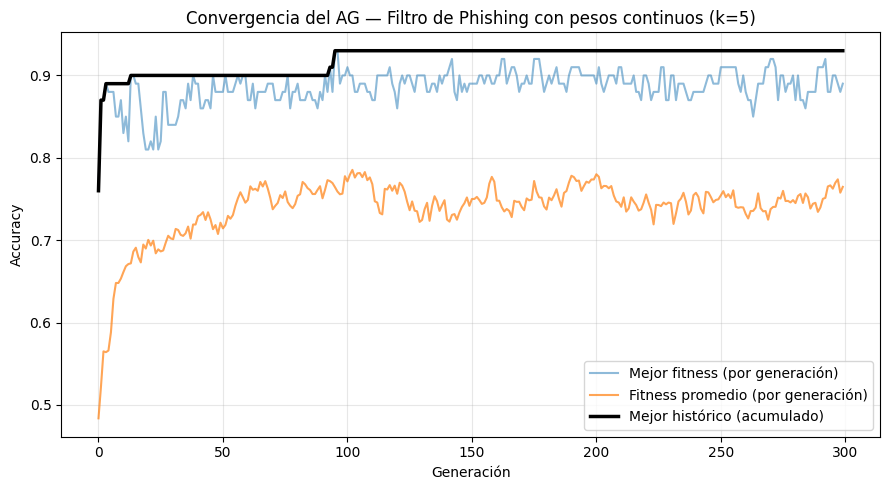

In [6]:
# --- Gráfica de convergencia ---
mejor_acumulado = np.maximum.accumulate(mejor_hist)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(mejor_hist,      label="Mejor fitness (por generación)",   alpha=0.5)
ax.plot(promedio_hist,   label="Fitness promedio (por generación)", alpha=0.7)
ax.plot(mejor_acumulado, label="Mejor histórico (acumulado)", linewidth=2.5, color="black")

ax.set_xlabel("Generación")
ax.set_ylabel("Accuracy")
ax.set_title("Convergencia del AG — Filtro de Phishing con pesos continuos (k=5)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Interpretación del mejor filtro encontrado (pesos continuos)

A diferencia de la versión bipolar, ahora cada barra no solo indica *si* una característica apunta a phishing o a legítimo, sino **cuánto** pesa esa evidencia. Por eso se anota el valor numérico exacto sobre cada barra: es la pieza central de "explicabilidad" para la sustentación.


Pesos continuos del mejor filtro encontrado por el AG:
              caracteristica   peso
                cuerpo_corto  0.935
                accion_legal  0.935
instruccion_confidencialidad  0.806
          palabras_clave_url  0.806
         asunto_verificacion  0.677
                  url_con_ip  0.613
              multiples_urls  0.548
             dominio_externo  0.355
  zona_horaria_inconsistente  0.355
        mismatch_dominio_url  0.355
       solo_enlace_sin_texto  0.161
       solicita_credenciales -0.032
           asunto_financiero -0.097
              mezcla_idiomas -0.097
               asunto_premio -0.161
    solicita_datos_bancarios -0.161
                ip_en_cuerpo -0.161
          suplantacion_marca -0.226
    destinatario_undisclosed -0.226
                url_acortada -0.355
             envio_madrugada -0.355
   nombre_display_sospechoso -0.355
                asunto_corto -0.355
        errores_ortograficos -0.419
            dominio_gratuito -0.419
         

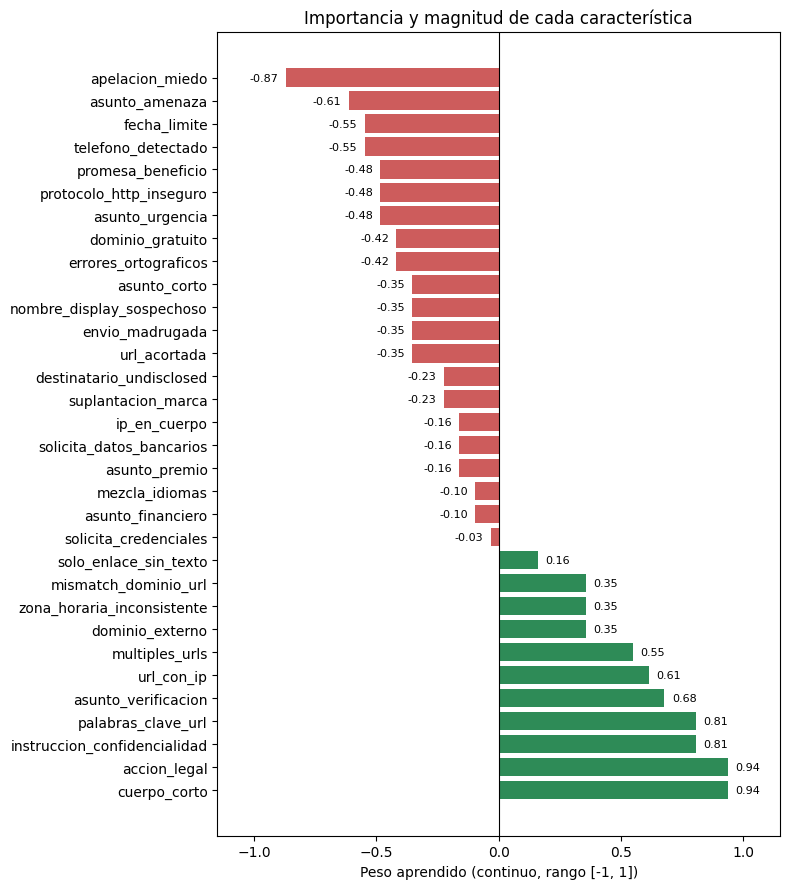

In [7]:
# --- Tabla de pesos del mejor individuo, ordenada de mayor a menor influencia ---
df_pesos = pd.DataFrame({
    "caracteristica": nombres_features,
    "peso": mejor_pesos_global
}).sort_values("peso", ascending=False).reset_index(drop=True)

print("Pesos continuos del mejor filtro encontrado por el AG:")
print(df_pesos.round(3).to_string(index=False))

# --- Gráfica de barras CON el valor numérico de cada peso (magnitud explícita) ---
colores = ["seagreen" if p > 0 else "indianred" for p in df_pesos["peso"]]

fig, ax = plt.subplots(figsize=(8, 9))
barras = ax.barh(df_pesos["caracteristica"], df_pesos["peso"], color=colores)
ax.set_xlim(-1.15, 1.15)                       # deja espacio para las etiquetas de texto
ax.set_xlabel("Peso aprendido (continuo, rango [-1, 1])")
ax.set_title("Importancia y magnitud de cada característica")
ax.axvline(0, color="black", linewidth=0.8)

# Anotar el valor numérico exacto al final de cada barra
for barra, valor in zip(barras, df_pesos["peso"]):
    desplazamiento = 0.03 if valor >= 0 else -0.03
    alineacion = "left" if valor >= 0 else "right"
    ax.text(valor + desplazamiento, barra.get_y() + barra.get_height()/2,
            f"{valor:.2f}", va="center", ha=alineacion, fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:
# --- Matriz de confusión del mejor filtro (calculada de forma vectorizada) ---
scores_final = X @ mejor_pesos_global
pred_final = (scores_final > 0).astype(int)

TP = np.sum((pred_final == 1) & (y == 1))   # phishing detectado correctamente
TN = np.sum((pred_final == 0) & (y == 0))   # legítimo detectado correctamente
FP = np.sum((pred_final == 1) & (y == 0))   # falsa alarma (legítimo marcado como phishing)
FN = np.sum((pred_final == 0) & (y == 1))   # phishing que se pasó por alto

print("Matriz de confusión del mejor filtro encontrado:")
print(f"                  Predicho Phishing   Predicho Legítimo")
print(f"Real Phishing            {TP:>3}                 {FN:>3}")
print(f"Real Legítimo            {FP:>3}                 {TN:>3}")
print(f"\nAccuracy verificado manualmente: {(TP + TN) / len(y):.2%}")


## 6. Techo teórico de Accuracy del dataset

Este número no depende del modelo, solo de los datos: existen correos con el **mismo vector de 32 características pero etiquetas distintas** (ruido/ambigüedad inherente al dataset), lo que impone un límite que ningún clasificador —lineal o no— podría superar usando solo estas 32 variables.


In [8]:
# --- Techo teórico de Accuracy impuesto por correos con features idénticas pero labels distintos ---
df_tmp = df.copy()
df_tmp["_grupo"] = df_tmp[nombres_features].apply(lambda fila: tuple(fila), axis=1)

aciertos_maximos_posibles = 0
filas_en_conflicto = 0
for _, etiquetas in df_tmp.groupby("_grupo")["label"]:
    conteo = etiquetas.value_counts()
    aciertos_maximos_posibles += conteo.max()
    if len(conteo) > 1:
        filas_en_conflicto += len(etiquetas)

techo_teorico = aciertos_maximos_posibles / len(df_tmp)

print(f"Correos con features idénticas pero etiquetas distintas: {filas_en_conflicto}")
print(f"Techo teórico de Accuracy (cualquier clasificador, basado solo en estas 32 features): {techo_teorico:.2%}")
print(f"Accuracy obtenido por el AG con pesos continuos (k={k_bits_por_peso})                : {mejor_fitness_global:.2%}")


Correos con features idénticas pero etiquetas distintas: 19
Techo teórico de Accuracy (cualquier clasificador, basado solo en estas 32 features): 97.00%
Accuracy obtenido por el AG con pesos continuos (k=5)                : 93.00%


## 7. Comparación empírica: pesos bipolares (k=1) vs. pesos continuos (k=5)

Para defender frente al docente *por qué* el enfoque continuo es superior, no basta con argumentarlo en teoría: aquí se comprueba directamente sobre el mismo dataset, bajo **exactamente las mismas condiciones** (misma población, mismas tasas de recombinación y mutación, mismas generaciones, misma semilla). Como se vio en la sección 1, `k=1` con rango $[-1,1]$ es matemáticamente idéntico a la codificación bipolar de la primera versión del proyecto — así que esta comparación es, literalmente, "versión anterior vs. versión nueva" usando el mismo código.


[k=1] Generaciones ejecutadas: 300 | Mejor Accuracy: 90.00%

--- Comparación bajo las MISMAS condiciones (n=60, tr=0.6, tm=0.01, maxiter=300, semilla=42) ---
Bipolar  (k=1, l= 32 bits) -> Accuracy: 90.00%
Continuo (k=5, l=160 bits) -> Accuracy: 93.00%
Ganancia de accuracy al usar pesos continuos: 3.0 puntos porcentuales


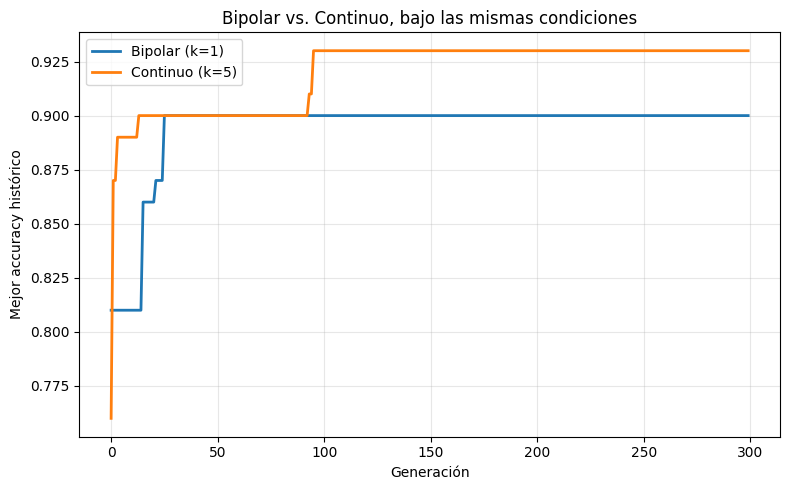

In [9]:
# --- Re-ejecutamos el mismo AG, pero con k=1 (equivalente a la versión bipolar anterior) ---
resultado_bipolar = ejecutar_ag(k=1)

print("\n--- Comparación bajo las MISMAS condiciones (n=60, tr=0.6, tm=0.01, maxiter=300, semilla=42) ---")
print(f"Bipolar  (k=1, l={n_bits*1:>3} bits) -> Accuracy: {resultado_bipolar['mejor_fitness']:.2%}")
print(f"Continuo (k=5, l={n_bits*5:>3} bits) -> Accuracy: {resultado_continuo['mejor_fitness']:.2%}")
print(f"Ganancia de accuracy al usar pesos continuos: "
      f"{(resultado_continuo['mejor_fitness'] - resultado_bipolar['mejor_fitness'])*100:.1f} puntos porcentuales")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.maximum.accumulate(resultado_bipolar["mejor_hist"]),  label="Bipolar (k=1)", linewidth=2)
ax.plot(np.maximum.accumulate(resultado_continuo["mejor_hist"]), label="Continuo (k=5)", linewidth=2)
ax.set_xlabel("Generación")
ax.set_ylabel("Mejor accuracy histórico")
ax.set_title("Bipolar vs. Continuo, bajo las mismas condiciones")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 8. Discusión y conclusiones

* Bajo las mismas condiciones, los pesos continuos (`k=5`) superan a los bipolares (`k=1`), porque el filtro ya no solo distingue *qué dirección* aporta cada característica, sino *cuánto* — por ejemplo, puede aprender que `solicita_datos_bancarios` pesa mucho más que `cuerpo_corto`, algo que la versión bipolar no podía expresar.
* El costo de esa ganancia es un cromosoma 5 veces más largo (160 vs. 32 bits) y, por lo tanto, un espacio de búsqueda mucho mayor ($2^{160}$ vs. $2^{32}$); por eso se necesitaron algunas generaciones adicionales y una tasa de mutación algo menor para mantener la búsqueda estable.
* El Accuracy obtenido sigue por debajo del techo teórico del dataset (calculado en la sección 6), lo cual es consistente con la ambigüedad/ruido ya identificado en los datos (correos con features idénticas pero etiquetas distintas) y con el hecho de que el filtro sigue siendo un modelo **lineal** con umbral fijo en 0.
* Posibles extensiones futuras: aumentar `k` aún más (p. ej. `k=8`) para una resolución casi continua, dejar que el AG también evolucione el umbral de decisión, o usar selección por torneo / elitismo explícito en vez de muestreo estocástico con resto.
